# Store Sales Forecasting Day 3: Feature Engineering + Baseline Model
**Goal:** Build a strong baseline model using only basic features, no lags or rolling windows yet.

**What this notebook does:**
1. Feature engineering: date features, categorical encoding, zero sales flag, transactions.
2. Create a baseline model using LGBM.
3. Save `train_fe.csv` and `test_fe.csv` for Day 4.

**Input:** `../data/train.csv` | `../data/test.csv`
**Output:** `../data/train_fe.csv` | `../data/test_fe.csv`
**Model:** `../models/baseline_lgbm.pkl`
**Submission:** `../submissions/submission_baseline.csv`

In [1]:
print("Import Libraries")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, pickle, os
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Success: Libraries imported")

Import Libraries
Success: Libraries imported


In [2]:
print("Load Day-2 outputs")
train = pd.read_csv('../data/train_clean.csv', parse_dates = ['date'])
test = pd.read_csv('../data/test_clean.csv', parse_dates = ['date'])

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Train date range: {train['date'].min()} -> {train['date'].max()}")
print(f"Test date range: {test['date'].min()} -> {test['date'].max()}")
print(f"Train columns: {train.columns.tolist()}")

print("Success: Day-2 outputs loaded")

Load Day-2 outputs
Train shape: (3000888, 34)
Test shape: (28512, 33)
Train date range: 2013-01-01 00:00:00 -> 2017-08-15 00:00:00
Test date range: 2017-08-16 00:00:00 -> 2017-08-31 00:00:00
Train columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'dcoilwtico', 'is_national_holiday', 'is_local_holiday', 'is_transferred_holiday', 'is_special_event', 'is_earthquake', 'year', 'month', 'day', 'dayofweek', 'weekofyear', 'quarter', 'dayofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'is_payday', 'days_to_payday', 'store_type_enc', 'family_enc', 'city_enc', 'state_enc', 'store_closed', 'txn_count']
Success: Day-2 outputs loaded


Target Transformation


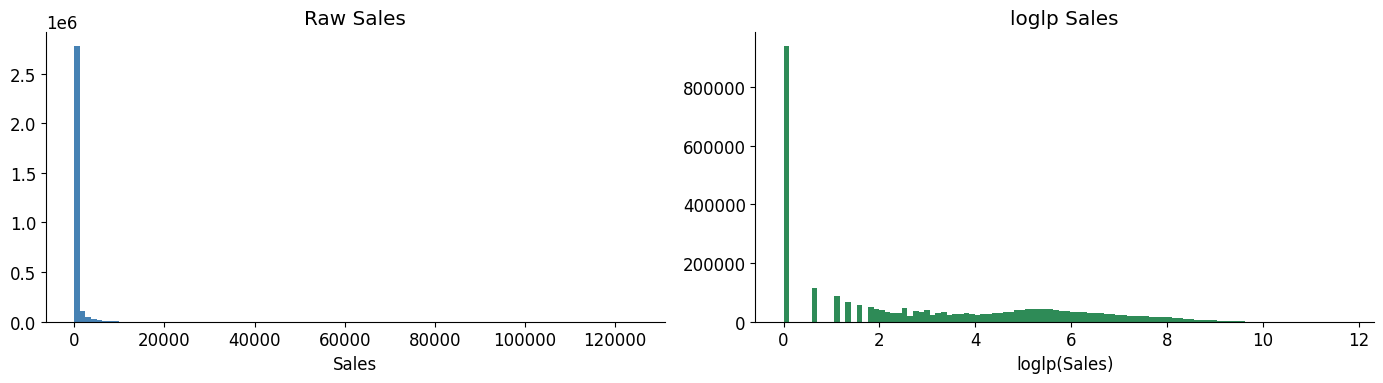

log1p(sales) mean: 2.9264
log1p(sales) std : 2.6951
Success: Target transformation completed


In [3]:
print("Target Transformation")

train['sales_log'] = np.log1p(train['sales'])

fig, axes = plt.subplots(1, 2, figsize = (14, 4))

axes[0].hist(train['sales'], bins = 100, color = 'steelblue', edgecolor = 'none')
axes[0].set_title("Raw Sales")
axes[0].set_xlabel('Sales')

axes[1].hist(train['sales_log'], bins = 100, color = 'seagreen', edgecolor = 'none')
axes[1].set_title("loglp Sales")
axes[1].set_xlabel('loglp(Sales)')

plt.tight_layout()
plt.savefig('../outputs/target-transformation.png', dpi = 150, bbox_inches = 'tight')
plt.show()

print(f"log1p(sales) mean: {train['sales_log'].mean():.4f}")
print(f"log1p(sales) std : {train['sales_log'].std():.4f}")

print("Success: Target transformation completed")

In [4]:
print("Date Features")

def add_date_features(df):
    df = df.copy()

    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['dayofyear'] = df['date'].dt.dayofyear
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    df['quarter'] = df['date'].dt.quarter
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['date'].dt.is_month_end.astype(int)

    # Cyclic Encoding
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

    return df

train = add_date_features(train)
test = add_date_features(test)

print("Success: Date features added")

Date Features
Success: Date features added


In [5]:
print("Sort train and test data")

train = train.sort_values(['store_nbr', 'family', 'date']).reset_index(drop = True)
test = test.sort_values(['store_nbr', 'family', 'date']).reset_index(drop = True)

print("Success: Train and test data sorted")

Sort train and test data
Success: Train and test data sorted


In [6]:
print("Lag features on train data")

lag_days = [7, 14, 21, 28, 35, 42, 56]

for lag in lag_days:
    train[f'sales_lag_{lag}'] = (train.groupby(['store_nbr', 'family'])['sales_log'].shift(lag))
    print(f"Created: sales_lag_{lag}")

train['sales_lag_364'] = (
    train.groupby(['store_nbr', 'family'])['sales_log']
         .shift(364)
)

train['sales_lag_365'] = (
    train.groupby(['store_nbr', 'family'])['sales_log']
         .shift(365)
)

print("Success: Lag features created on train data")

Lag features on train data
Created: sales_lag_7
Created: sales_lag_14
Created: sales_lag_21
Created: sales_lag_28
Created: sales_lag_35
Created: sales_lag_42
Created: sales_lag_56
Success: Lag features created on train data


In [7]:
print("Rolling Features on train data")

rolling_windows = [7, 14, 28]

for window in rolling_windows:
    grouped = train.groupby(['store_nbr', 'family', ])['sales_log']
    train[f'rolling_mean_{window}'] = grouped.transform(lambda x: x.shift(1).rolling(window, min_periods = 1).mean())
    train[f'rolling_std_{window}'] = grouped.transform(lambda x: x.shift(1).rolling(window, min_periods = 1).std().fillna(0))
    print(f"Created: rolling_mean_{window} and rolling_std_{window}")

train['rolling_mean_lw'] = (
    train.groupby(['store_nbr', 'family'])['sales_log']
         .transform(lambda x: x.shift(364).rolling(7, min_periods=1).mean())
)

train['rolling_std_lw'] = (
    train.groupby(['store_nbr', 'family'])['sales_log']
         .transform(lambda x: x.shift(364).rolling(7, min_periods=1).std().fillna(0))
)

print("Success: Rolling features created on train data")

Rolling Features on train data
Created: rolling_mean_7 and rolling_std_7
Created: rolling_mean_14 and rolling_std_14
Created: rolling_mean_28 and rolling_std_28
Success: Rolling features created on train data


In [8]:
print("test lags from last train history")

history = train[['date', 'store_nbr', 'family', 'sales_log']].copy()

for lag in lag_days:
    lag_map = (
        history.groupby(['store_nbr', 'family']).tail(lag).groupby(['store_nbr', 'family'])['sales_log'].apply(list).reset_index(name = f'lag_list_{lag}')
    )

    test = test.merge(lag_map, on = ['store_nbr', 'family'], how = 'left')

def extract_lag(lst, pos_from_end):
    if isinstance(lst, list) and len(lst) >= pos_from_end:
        return lst[-pos_from_end]
    else:
        return np.nan
    
for lag in lag_days:
    test[f'sales_lag_{lag}'] = test[f'lag_list_{lag}'].apply(lambda x: extract_lag(x, lag))
    print(f"Created: sales_lag_{lag} in test data")

test = test.drop(columns=[f'lag_list_{lag}' for lag in lag_days])

print("Success: Lag features created in test data from last train history")

test lags from last train history
Created: sales_lag_7 in test data
Created: sales_lag_14 in test data
Created: sales_lag_21 in test data
Created: sales_lag_28 in test data
Created: sales_lag_35 in test data
Created: sales_lag_42 in test data
Created: sales_lag_56 in test data
Success: Lag features created in test data from last train history


In [9]:
print("Test rolling features from last train history")

for window in rolling_windows:
    roll_map = (
        history.groupby(['store_nbr', 'family'])['sales_log'].apply(lambda x : x.tail(window).mean()).reset_index(name = f'rolling_mean_{window}')
    )

    test = test.merge(roll_map, on = ['store_nbr', 'family'], how = 'left')

    roll_std_map = (
        history.groupby(['store_nbr', 'family'])['sales_log'].apply(lambda x : x.tail(window).std()).reset_index(name = f'rolling_std_{window}')
    )

    test = test.merge(roll_std_map, on = ['store_nbr', 'family'], how = 'left')

    print(f"Created: rolling_mean_{window} and rolling_std_{window} in test data")

print("Success: Rolling features created in test data from last train history")

Test rolling features from last train history
Created: rolling_mean_7 and rolling_std_7 in test data
Created: rolling_mean_14 and rolling_std_14 in test data
Created: rolling_mean_28 and rolling_std_28 in test data
Success: Rolling features created in test data from last train history


In [10]:
print("Oil Features")

if 'dcoilwtico' in train.columns:
    train['oil_lag7'] = train.groupby(['store_nbr', 'family'])['dcoilwtico'].shift(7)
    train['oil_lag14'] = train.groupby(['store_nbr', 'family'])['dcoilwtico'].shift(14)

    train['oil_rolling_mean_7'] = train.groupby(['store_nbr', 'family'])['dcoilwtico'].transform(lambda x: x.shift(1).rolling(7, min_periods = 1).mean())

    test['oil_lag7'] = test['dcoilwtico']
    test['oil_lag14'] = test['dcoilwtico']

    test['oil_rolling_mean_7'] = test['dcoilwtico']

    print("Success: Oil features created")

else:
    print("Error: 'dcoilwtico' column not found in train data.")

Oil Features
Success: Oil features created


In [11]:
print("Holiday Proximity Features")

if 'is_national_holiday' in train.columns:
    all_dates = pd.concat([train[['date', 'is_national_holiday']], test[['date', 'is_national_holiday']]], axis = 0).drop_duplicates()

    holiday_dates = sorted(all_dates.loc[all_dates['is_national_holiday'] == 1, 'date'].unique())

    def days_to_next_holiday(d):
        future = [h for h in holiday_dates if h > d]
        return (future[0] - d).days if len(future) > 0 else 30
    
    def days_since_last_holiday(d):
        past = [h for h in holiday_dates if h < d]
        return (d - past[-1]).days if len(past) > 0 else 30
    
    for df in [train, test]:
        df['days_to_next_hol'] = df['date'].apply(days_to_next_holiday).clip(0, 30)
        df['days_since_last_hol'] = df['date'].apply(days_since_last_holiday).clip(0, 30)

    print("Success: Holiday proximity features created")

else:
    print("Error: 'is_national_holiday' column not found in train data.")

Holiday Proximity Features
Success: Holiday proximity features created


In [12]:
print("Store-family aggregate features")

agg = (
    train.groupby(['store_nbr', 'family'])['sales_log'].agg(['mean', 'median', 'std', 'max']).reset_index().rename(columns = {
        'mean' : 'sf_mean_sales',
        'median' : 'sf_median_sales',
        'std' : 'sf_std_sales',
        'max' : 'sf_max_sales'
    })
)

train = train.merge(agg, on = ['store_nbr', 'family'], how = 'left')
test = test.merge(agg, on = ['store_nbr', 'family'], how = 'left')

print("Success: Store-family aggregate features created")

Store-family aggregate features
Success: Store-family aggregate features created


In [13]:
dow_agg = (
    train.groupby(['store_nbr', 'family', 'dayofweek'])['sales_log']
         .mean()
         .reset_index(name='sf_dow_mean')
)
train = train.merge(dow_agg, on=['store_nbr', 'family', 'dayofweek'], how='left')
test  = test.merge(dow_agg,  on=['store_nbr', 'family', 'dayofweek'], how='left')

# Average sales per (store, family, month)
month_agg = (
    train.groupby(['store_nbr', 'family', 'month'])['sales_log']
         .mean()
         .reset_index(name='sf_month_mean')
)
train = train.merge(month_agg, on=['store_nbr', 'family', 'month'], how='left')
test  = test.merge(month_agg,  on=['store_nbr', 'family', 'month'], how='left')

In [14]:
print("Promotion Features")

if 'onpromotion' in train.columns:
    promo_ratio = (
        train.groupby(['store_nbr', 'family'])['onpromotion'].mean().reset_index(name = 'sf_promo_ratio')
    )

    train = train.merge(promo_ratio, on = ['store_nbr', 'family'], how = 'left')
    test = test.merge(promo_ratio, on = ['store_nbr', 'family'], how = 'left')

    train['promo_roll7'] = (
        train.groupby(['store_nbr', 'family'])['onpromotion'].transform(lambda x: x.shift(1).rolling(7, min_periods = 1).sum())
    )
    test['promo_roll7'] = test['onpromotion']

    print("Success: Promotion features created")

Promotion Features
Success: Promotion features created


In [15]:
print("Fill missing values")

train = train.fillna(0)
test = test.fillna(0)

print(train.isnull().sum().sum())
print(test.isnull().sum().sum())
print("Success: Missing values filled")

Fill missing values
0
0
Success: Missing values filled


In [16]:
print("Feature list")

FEATURES = [
    'store_nbr', 'family_enc', 'cluster',
    'store_type_enc',
    'year', 'month', 'day', 'dayofweek', 'dayofyear',
    'weekofyear', 'quarter', 'is_weekend',
    'is_month_start', 'is_month_end',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',

    'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'rolling_mean_7', 'rolling_std_7',
    'rolling_mean_14', 'rolling_std_14',
    'rolling_mean_28', 'rolling_std_28', 'sales_lag_21', 'sales_lag_35', 'sales_lag_42', 'sales_lag_56',
'sales_lag_364', 'sales_lag_365', 'rolling_mean_lw', 'rolling_std_lw',

    'oil_lag7', 'oil_lag14', 'oil_rolling_mean7',

    'is_national_holiday', 'is_local_holiday', 'is_transferred',
    'days_to_next_hol', 'days_since_last_hol',

    'sf_mean_sales', 'sf_median_sales', 'sf_std_sales', 'sf_max_sales', 'sf_dow_mean', 'sf_month_mean',

    'onpromotion', 'sf_promo_ratio', 'promo_roll7'
]

FEATURES = [f for f in FEATURES if f in train.columns]
TARGET = 'sales_log'

print(f"Total features: {len(FEATURES)}")
print(FEATURES)

print("Success: Feature list created")

Feature list
Total features: 50
['store_nbr', 'family_enc', 'cluster', 'store_type_enc', 'year', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28', 'rolling_std_28', 'sales_lag_21', 'sales_lag_35', 'sales_lag_42', 'sales_lag_56', 'sales_lag_364', 'sales_lag_365', 'rolling_mean_lw', 'rolling_std_lw', 'oil_lag7', 'oil_lag14', 'is_national_holiday', 'is_local_holiday', 'days_to_next_hol', 'days_since_last_hol', 'sf_mean_sales', 'sf_median_sales', 'sf_std_sales', 'sf_max_sales', 'sf_dow_mean', 'sf_month_mean', 'onpromotion', 'sf_promo_ratio', 'promo_roll7']
Success: Feature list created


In [17]:
print("Time based validation split")
val_cutoff = train['date'].max() - pd.Timedelta(days = 15)

train_df = train[train['date'] < val_cutoff].copy()
val_df = train[train['date'] >= val_cutoff].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_val = val_df[FEATURES]
y_val = val_df[TARGET]

print(f"Train rows: {X_train.shape}")
print(f"Val rows: {X_val.shape}")
print(f"Validation starts from: {val_cutoff}")

print("Success: Time based validation split completed")

Time based validation split
Train rows: (2972376, 50)
Val rows: (28512, 50)
Validation starts from: 2017-07-31 00:00:00
Success: Time based validation split completed


In [18]:
print("Baseline Model: LightGBM")

%pip install lightgbm

import lightgbm as lgb

model = lgb.LGBMRegressor(
    objective = 'regression',
    metric = 'rmse',
    num_leaves = 255,
    learning_rate = 0.02,
    feature_fraction = 0.8,
    bagging_fraction = 0.8,
    bagging_freq = 5,
    min_child_samples = 50,
    n_estimators = 3000,
    random_state = 42,
    n_jobs = -1
)

model.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],
    callbacks = [
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

print("Success: Baseline LightGBM model trained")

Baseline Model: LightGBM



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.121055 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM]

In [19]:
print("Training per-family LightGBM models")

family_models = {}
family_val_scores = {}

families = train['family'].unique()

lgb_params_family = {
    'objective': 'regression',
    'metric': 'rmse',
    'num_leaves': 63,         
    'learning_rate': 0.03,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 10,
    'n_estimators': 1000,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

from sklearn.metrics import mean_squared_error

for fam in families:
    tr = train_df[train_df['family'] == fam]
    vl = val_df[val_df['family'] == fam]

    if len(tr) < 500:     
        continue

    X_tr = tr[FEATURES]
    y_tr = tr[TARGET]
    X_vl = vl[FEATURES]
    y_vl = vl[TARGET]

    m = lgb.LGBMRegressor(**lgb_params_family)
    m.fit(
        X_tr, y_tr,
        eval_set=[(X_vl, y_vl)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=0)]
    )

    preds = m.predict(X_vl)
    preds = np.clip(preds, 0, None)
    score = np.sqrt(mean_squared_error(y_vl, preds))
    family_models[fam] = m
    family_val_scores[fam] = score

scores_df = pd.DataFrame({
    'family': list(family_val_scores.keys()),
    'rmse_log': list(family_val_scores.values())
}).sort_values('rmse_log', ascending=False)

print(scores_df.to_string())
print(f"\nMean family RMSE: {scores_df['rmse_log'].mean():.4f}")
print(f"Families trained: {len(family_models)}")

Training per-family LightGBM models
                        family  rmse_log
21                    LINGERIE    0.6063
13                  GROCERY II    0.5368
6                  CELEBRATION    0.5255
14                    HARDWARE    0.5229
23                   MAGAZINES    0.5003
0                   AUTOMOTIVE    0.4961
31  SCHOOL AND OFFICE SUPPLIES    0.4931
19                  LADIESWEAR    0.4720
32                     SEAFOOD    0.4696
27     PLAYERS AND ELECTRONICS    0.4626
15          HOME AND KITCHEN I    0.4616
2                       BEAUTY    0.4602
26                PET SUPPLIES    0.4569
16         HOME AND KITCHEN II    0.4383
22            LIQUOR,WINE,BEER    0.4196
20             LAWN AND GARDEN    0.4144
17             HOME APPLIANCES    0.2960
10                        EGGS    0.2910
1                    BABY CARE    0.2703
29              PREPARED FOODS    0.2663
11                FROZEN FOODS    0.2562
7                     CLEANING    0.2329
24                   

In [20]:
print("Validation Metrics")

from sklearn.metrics import mean_squared_error, mean_absolute_error

val_preds_log = model.predict(X_val)
val_preds_log = np.clip(val_preds_log, a_min = 0, a_max = None)

val_preds = np.expm1(val_preds_log)
y_val_raw = np.expm1(y_val)

rmse_log = np.sqrt(mean_squared_error(y_val, val_preds_log))
rmsle = np.sqrt(mean_squared_error(np.log1p(y_val_raw), np.log1p(val_preds)))
mae = mean_absolute_error(y_val_raw, val_preds)

print(f"Validation RMSE (log): {rmse_log:.4f}")
print(f"RMSLE: {rmsle:.4f}")
print(f"MAE: {mae:.4f}")

Validation Metrics
Validation RMSE (log): 0.3678
RMSLE: 0.3678
MAE: 55.7677


Feature Importance
             feature  importance
22     rolling_std_7       31274
21    rolling_mean_7       26821
6                day       26222
45       sf_dow_mean       26122
8          dayofyear       25313
24    rolling_std_14       24457
26    rolling_std_28       24371
35          oil_lag7       20591
46     sf_month_mean       20547
25   rolling_mean_28       19577
0          store_nbr       19115
43      sf_std_sales       18519
48    sf_promo_ratio       18249
36         oil_lag14       18150
23   rolling_mean_14       17953
34    rolling_std_lw       17902
18       sales_lag_7       17637
41     sf_mean_sales       17481
1         family_enc       15674
39  days_to_next_hol       15594


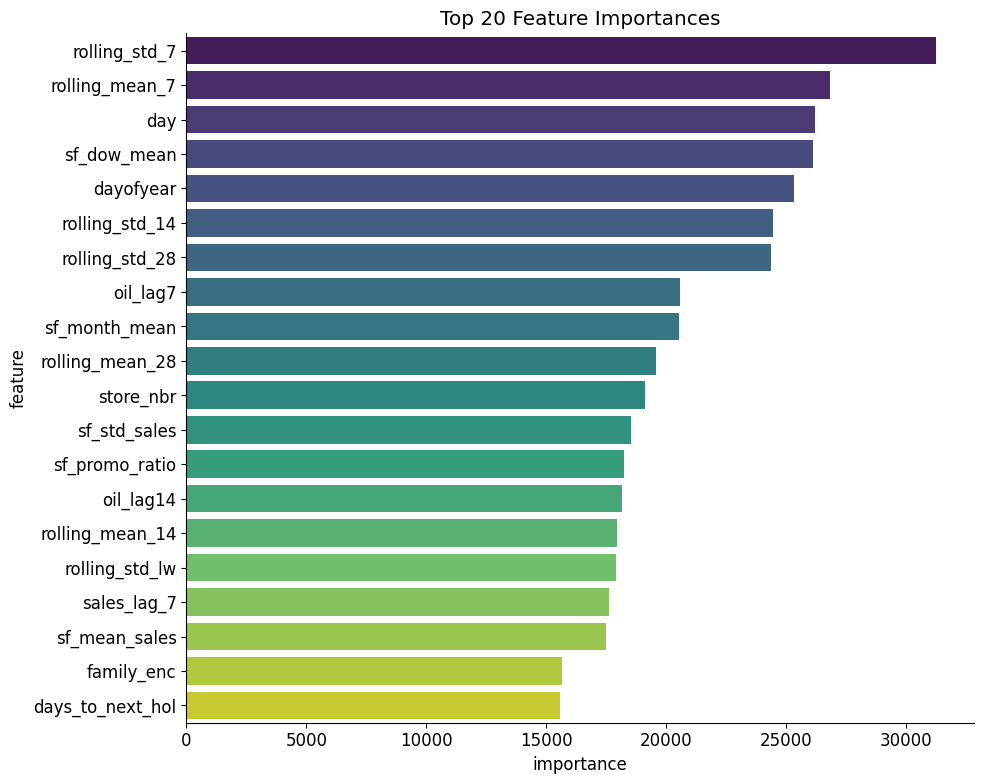

In [21]:
print("Feature Importance")

importance_df = pd.DataFrame({
    'feature' : FEATURES,
    'importance' : model.feature_importances_
}).sort_values('importance', ascending = False)

print(importance_df.head(20))

plt.figure(figsize = (10, 8))
sns.barplot(data = importance_df.head(20), x = 'importance', y = 'feature', palette = 'viridis')
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.savefig('../outputs/feature-importance.png', dpi = 150, bbox_inches = 'tight')
plt.show()

Residual Analysis


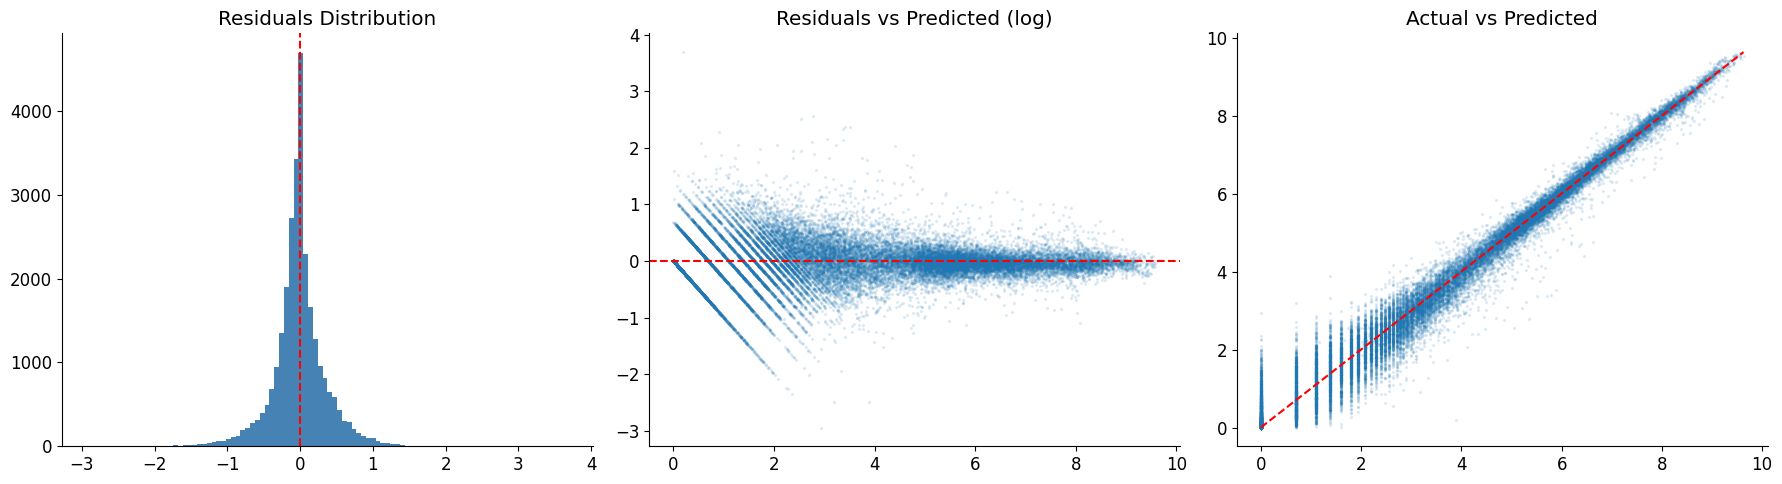

In [22]:
print("Residual Analysis")

residuals = y_val - val_preds_log

fig, axes = plt.subplots(1, 3, figsize = (18, 5))

axes[0].hist(residuals, bins = 100, color = 'steelblue', edgecolor = 'none')
axes[0].axvline(0, color = 'red', linestyle = '--')
axes[0].set_title("Residuals Distribution")

axes[1].scatter(val_preds_log, residuals, alpha = 0.1, s = 2)
axes[1].axhline(0, color = 'red', linestyle = '--')
axes[1].set_title("Residuals vs Predicted (log)")

axes[2].scatter(y_val, val_preds_log, alpha = 0.1, s = 2)
axes[2].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
axes[2].set_title("Actual vs Predicted")

plt.tight_layout()
plt.savefig('../outputs/residual-analysis.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [23]:
print("Predict Test Set")

missing_features = [col for col in FEATURES if col not in test.columns]
for col in missing_features:
    test[col] = 0

X_test = test[FEATURES]
test_preds_log = model.predict(X_test)
test_preds_log = np.clip(test_preds_log, a_min = 0, a_max = None)
test_preds = np.expm1(test_preds_log)

submission = pd.DataFrame({
    'id' : test['id'],
    'sales' : test_preds
})

submission.to_csv('../submissions/submission_baseline.csv', index = False)

print(submission.head())

print("Success: Test set predictions saved to submission_baseline.csv")

Predict Test Set
        id  sales
0  3000888 4.2556
1  3002670 3.8056
2  3004452 4.1996
3  3006234 4.4298
4  3008016 2.1656
Success: Test set predictions saved to submission_baseline.csv


In [24]:
test_preds_family = np.zeros(len(test))

for fam in families:
    mask = test['family'] == fam
    X_fam = test.loc[mask, FEATURES]

    if fam in family_models:
        preds = family_models[fam].predict(X_fam)
    else:
        preds = model.predict(X_fam)   # fallback to global

    test_preds_family[mask] = np.clip(preds, 0, None)

test_preds_final = np.expm1(test_preds_family)

submission_v2 = pd.DataFrame({
    'id': test['id'],
    'sales': test_preds_final
})

submission_v2.to_csv('../submissions/submission_v2_family_models.csv', index=False)
print("✅ Per-family submission saved")

✅ Per-family submission saved


In [25]:
print("Save Data + Featured Data")

with open('../models/baseline_lgbm.pkl', 'wb') as f:
    pickle.dump(model, f)

train.to_csv('../data/train_fe.csv', index = False)
test.to_csv('../data/test_fe.csv', index = False)

print("Success: Data saved to train_fe.csv and test_fe.csv")

Save Data + Featured Data
Success: Data saved to train_fe.csv and test_fe.csv
